In [104]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

In [79]:
m = 5
n = 9

res_x = 1.0
res_y = 1.0

G = nx.Graph()
for i in range(m):
    for j in range(n):
        if i < m-1:
            G.add_edge((i,j),(i+1,j),label=str(i)+"_"+str(i+1)+"__"+str(j),res=res_x)
        if j < n-1:
            G.add_edge((i,j),(i,j+1),label=str(i)+"__"+str(j)+"_"+str(j+1),res=res_y)

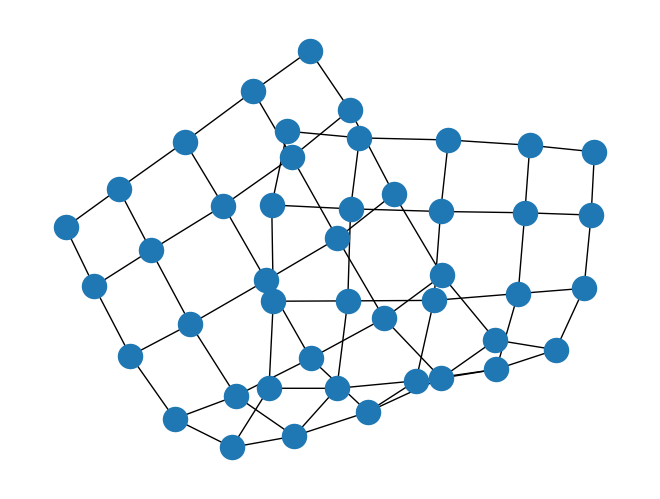

In [81]:
nx.draw_spring(G)

In [82]:
nx.resistance_distance(G,(0,0),(m-1,n-1),weight='res')

2.827490805862467

In [141]:
# power of two refinement study

init_m = 20
init_n = 20

res_x = 1.0
res_y = 1.0

num_refinement = 5

size_x = [init_m]
size_y = [init_n]
for k in range(num_refinement):
    size_x = size_x + [2*size_x[-1]-1]
    size_y = size_y + [2*size_y[-1]-1]

G = [nx.Graph() for g in range(num_refinement)]
factors = [2**k for k in range(num_refinement)]

for k in range(num_refinement):
    for i in range(size_x[k]):
        for j in range(size_y[k]):
            if i < size_x[k]-1:
                G[k].add_edge((i,j),(i+1,j),label=str(i)+"_"+str(i+1)+"__"+str(j),res=res_x/np.sqrt(factors[k]))
            if j < size_y[k]-1:
                G[k].add_edge((i,j),(i,j+1),label=str(i)+"__"+str(j)+"_"+str(j+1),res=res_y/np.sqrt(factors[k]))

In [142]:
diag_res = [0 for k in range(num_refinement)]
for k in range(num_refinement):
    diag_res[k] = nx.resistance_distance(G[k],(0,0),(size_x[k]-1,size_y[k]-1),weight='res')
    print(diag_res[k])

<class 'networkx.utils.decorators.argmap'> compilation 28:4: FutureWarning: laplacian_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.


3.8922655409038587
3.353160571298905
2.8040342962711016
2.2918330443051254
1.8401622290172048


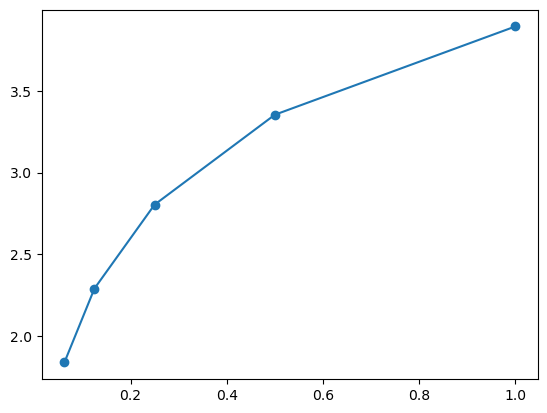

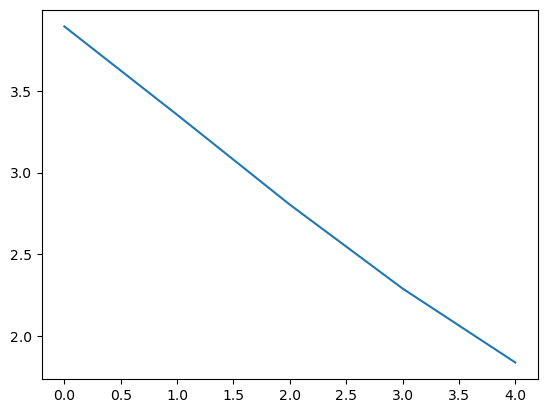

In [143]:
plt.figure()
plt.plot([1./f for f in factors],np.array(diag_res),marker='o')
plt.figure()
plt.plot(diag_res)

In [ ]:
from scipy.optimize import curve_fit

def exponential_model(x, a, b, c):
    return a * np.exp(b * x) + c

popt, pcov = curve_fit(exponential_model, factors, diag_res, p0=(1.0, 0.1, 0.1))

In [ ]:
plt.plot([exponential_model(i,popt[0],popt[1],popt[2]) for i in factors],marker='x')